# MS1 Analysis Exploration
This notebook is for visually exploring the transcript and QA dataset to analyze character and token lengths.
Note: You may need to run `pip install matplotlib jupyter` (or use conda) if it's not installed in your active environment.

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path so we can import src modules
project_root = Path("../../").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.common.paths import resolve_ms1_paths
from src.ms1.ingest.loader import load_transcripts, load_qa_files, validate_pairing
from src.ms1.profiling.corpus_stats import compute_text_stats

# Matplotlib for visualization
import matplotlib.pyplot as plt

## Load Data

In [2]:
paths = resolve_ms1_paths(repo_root=project_root)

transcripts = load_transcripts(paths)
qa_records = load_qa_files(paths)
pairing_map = validate_pairing(paths)

print(f"Transcripts loaded: {len(transcripts)}")
print(f"QA records loaded: {len(qa_records)}")
print(f"Paired transcript titles: {len(pairing_map)}")

Transcripts loaded: 13
QA records loaded: 3890
Paired transcript titles: 13


## Compute Statistics

In [3]:
transcript_texts = [t["content"] for t in transcripts]
question_texts = [r["question"] for r in qa_records if r.get("question")]
answer_texts = [r["answer"] for r in qa_records if r.get("answer")]

stats = {
    "transcripts": compute_text_stats(transcript_texts),
    "questions": compute_text_stats(question_texts),
    "answers": compute_text_stats(answer_texts),
}

print(f"Transcript texts: {len(transcript_texts)}")
print(f"Question texts: {len(question_texts)}")
print(f"Answer texts: {len(answer_texts)}")
print(f"Transcript token mean: {stats['transcripts']['tokens']['mean']:.2f}")
print(f"Question token mean: {stats['questions']['tokens']['mean']:.2f}")
print(f"Answer token mean: {stats['answers']['tokens']['mean']:.2f}")

Transcript texts: 13
Question texts: 3890
Answer texts: 3890
Transcript token mean: 6875.23
Question token mean: 6.08
Answer token mean: 4.94


## Visualizations

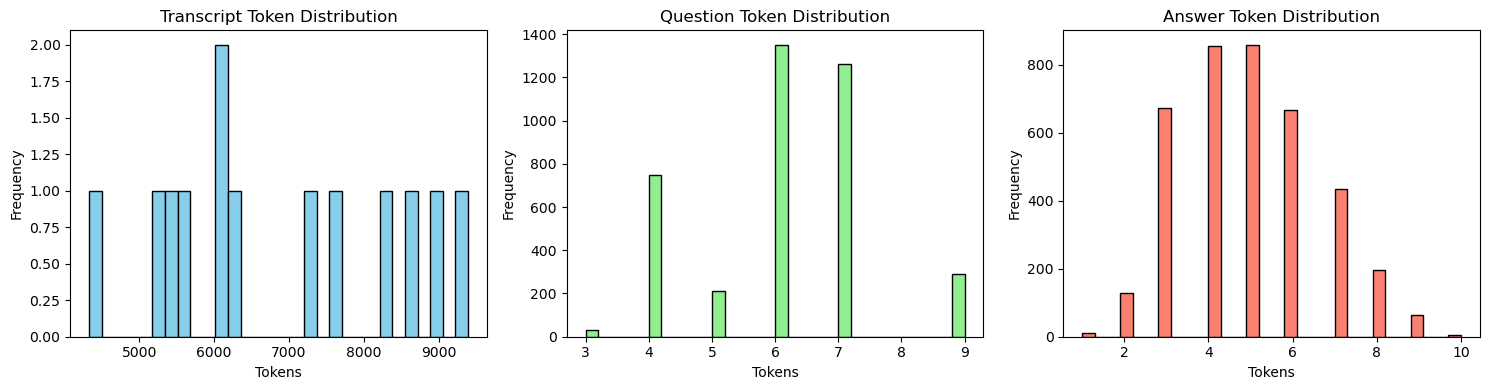

In [4]:
transcript_token_counts = [len(text.split()) for text in transcript_texts]
question_token_counts = [len(text.split()) for text in question_texts]
answer_token_counts = [len(text.split()) for text in answer_texts]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(transcript_token_counts, bins=30, color="skyblue", edgecolor="black")
plt.title("Transcript Token Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(question_token_counts, bins=30, color="lightgreen", edgecolor="black")
plt.title("Question Token Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(answer_token_counts, bins=30, color="salmon", edgecolor="black")
plt.title("Answer Token Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Duration Analysis (from transcript timestamps)
We estimate video duration by parsing timestamped transcript lines like `12.345: ...` and taking each file's maximum timestamp.
This gives a practical approximation of video length in minutes.

Videos analyzed: 13
Average video length (mm:ss): 35:20
Median video length (mm:ss): 31:28
Min/Max video length (mm:ss): 21:42 / 51:01
Average words per minute (rough): 194.97

Shortest 3 videos:
- ‫تاج محل  الدحيح‬ -> 21:42
- ‫هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح‬ -> 28:09
- ‫الساموراي  الدحيح‬ -> 28:57

Longest 3 videos:
- ‫منابع النيل  الدحيح‬ -> 43:59
- ‫جون كينيدي  الدحيح‬ -> 45:55
- ‫كيف تحولت روسيا إلى إمبراطورية؟  الدحيح‬ -> 51:01


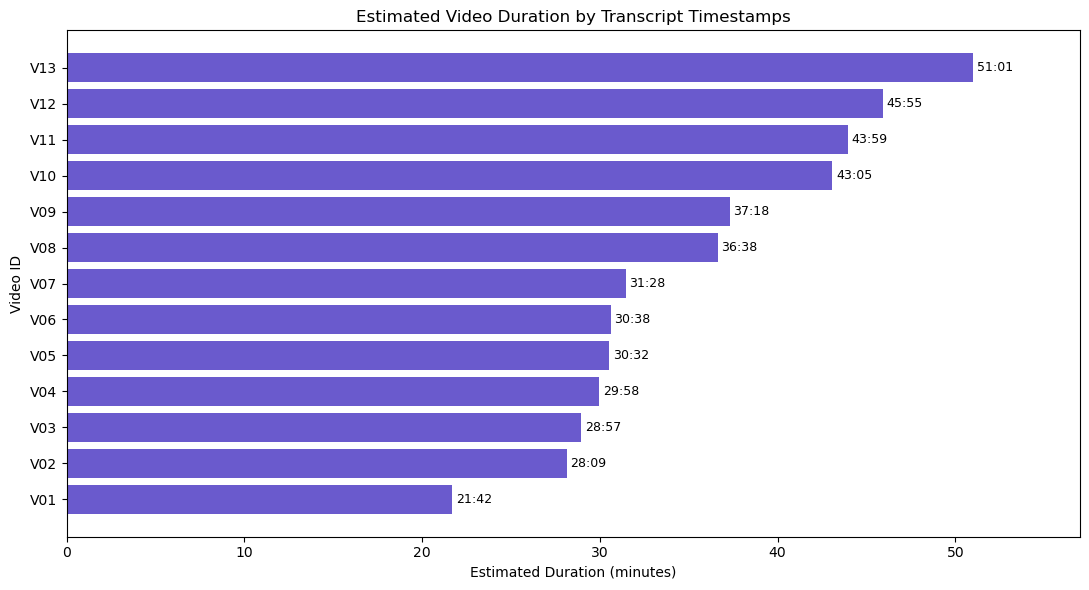


Video ID mapping (short -> full title):
V01: ‫تاج محل  الدحيح‬ (21:42)
V02: ‫هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح‬ (28:09)
V03: ‫الساموراي  الدحيح‬ (28:57)
V04: ‫مصير الأرض و الشمس و كل شيء  الدحيح‬ (29:58)
V05: ‫الأخطبوط  الدحيح‬ (30:32)
V06: ‫أعظم طائرة حربية  الدحيح‬ (30:38)
V07: ‫كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح‬ (31:28)
V08: ‫فيزياء و فلسفة الحركة  الدحيح‬ (36:38)
V09: ‫كيف تسيطر على عقول البشر؟  الدحيح‬ (37:18)
V10: ‫معركة ذي قار  الدحيح‬ (43:05)
V11: ‫منابع النيل  الدحيح‬ (43:59)
V12: ‫جون كينيدي  الدحيح‬ (45:55)
V13: ‫كيف تحولت روسيا إلى إمبراطورية؟  الدحيح‬ (51:01)


In [5]:
import re
import statistics

timestamp_pattern = re.compile(r"^\s*(\d+(?:\.\d+)?)\s*:\s*")


def format_seconds_to_mmss(total_seconds: float) -> str:
    total_seconds_int = max(0, int(round(total_seconds)))
    minutes, seconds = divmod(total_seconds_int, 60)
    return f"{minutes:02d}:{seconds:02d}"


def format_arabic_label(text: str) -> str:
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display

        return get_display(arabic_reshaper.reshape(text))
    except Exception:
        return f"\u202b{text}\u202c"


duration_rows = []
for transcript in transcripts:
    timestamps = []
    for line in transcript["content"].splitlines():
        match = timestamp_pattern.match(line)
        if match:
            timestamps.append(float(match.group(1)))

    if not timestamps:
        continue

    max_ts_sec = max(timestamps)
    min_ts_sec = min(timestamps)
    span_sec = max_ts_sec - min_ts_sec

    token_count = len(transcript["content"].split())
    words_per_min = token_count / (max_ts_sec / 60.0) if max_ts_sec > 0 else 0.0

    duration_rows.append(
        {
            "video_id": transcript["video_id"],
            "timestamp_count": len(timestamps),
            "first_ts_sec": min_ts_sec,
            "last_ts_sec": max_ts_sec,
            "duration_sec": max_ts_sec,
            "speech_span_sec": span_sec,
            "token_count": token_count,
            "words_per_min": words_per_min,
        }
    )

if not duration_rows:
    raise ValueError("No timestamped lines were found in transcripts.")

durations_sec = [row["duration_sec"] for row in duration_rows]
wpm_values = [row["words_per_min"] for row in duration_rows]

print(f"Videos analyzed: {len(duration_rows)}")
print(
    f"Average video length (mm:ss): "
    f"{format_seconds_to_mmss(statistics.mean(durations_sec))}"
)
print(
    f"Median video length (mm:ss): "
    f"{format_seconds_to_mmss(statistics.median(durations_sec))}"
)
print(
    f"Min/Max video length (mm:ss): "
    f"{format_seconds_to_mmss(min(durations_sec))} / "
    f"{format_seconds_to_mmss(max(durations_sec))}"
)
print(f"Average words per minute (rough): {statistics.mean(wpm_values):.2f}")

# Show longest and shortest videos
sorted_by_duration = sorted(duration_rows, key=lambda row: row["duration_sec"])
print("\nShortest 3 videos:")
for row in sorted_by_duration[:3]:
    print(
        f"- {format_arabic_label(row['video_id'])} -> {format_seconds_to_mmss(row['duration_sec'])}"
    )

print("\nLongest 3 videos:")
for row in sorted_by_duration[-3:]:
    print(
        f"- {format_arabic_label(row['video_id'])} -> {format_seconds_to_mmss(row['duration_sec'])}"
    )

# Plot using compact IDs to avoid long Arabic labels squeezing the figure
plot_rows = sorted_by_duration
video_ids = [f"V{idx:02d}" for idx in range(1, len(plot_rows) + 1)]
values_min = [row["duration_sec"] / 60.0 for row in plot_rows]

plt.figure(figsize=(11, 6))
bars = plt.barh(video_ids, values_min, color="slateblue")

for bar, row in zip(bars, plot_rows):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        format_seconds_to_mmss(row["duration_sec"]),
        ha="left",
        va="center",
        fontsize=9,
    )

plt.xlim(0, max(values_min) + 6)
plt.xlabel("Estimated Duration (minutes)")
plt.ylabel("Video ID")
plt.title("Estimated Video Duration by Transcript Timestamps")
plt.tight_layout()
plt.show()

print("\nVideo ID mapping (short -> full title):")
for idx, row in enumerate(plot_rows, start=1):
    print(
        f"V{idx:02d}: {format_arabic_label(row['video_id'])} "
        f"({format_seconds_to_mmss(row['duration_sec'])})"
    )

## Export Duration Findings to MS1 Report
This cell appends (or updates) an auto-generated duration addendum in `experiments/ms1/ms1_profiling_corpus_summary_v001.md`.

In [6]:
from datetime import datetime
import re


def to_mmss(total_seconds: float) -> str:
    total_seconds_int = max(0, int(round(total_seconds)))
    minutes, seconds = divmod(total_seconds_int, 60)
    return f"{minutes:02d}:{seconds:02d}"


def replace_or_append_block(
    content: str, start_marker: str, end_marker: str, block: str
) -> str:
    if start_marker in content and end_marker in content:
        pattern = rf"{re.escape(start_marker)}.*?{re.escape(end_marker)}"
        return re.sub(pattern, block, content, flags=re.S)
    return content.rstrip() + "\n\n" + block + "\n"


if "duration_rows" not in globals() or not duration_rows:
    raise ValueError("Run the Duration Analysis cell first.")

report_path = (
    project_root / "experiments" / "ms1" / "ms1_profiling_corpus_summary_v001.md"
)
if not report_path.exists():
    raise FileNotFoundError(f"Report file not found: {report_path}")

rows_sorted = sorted(duration_rows, key=lambda row: row["duration_sec"])
durations_sec = [row["duration_sec"] for row in rows_sorted]
wpm_values = [row["words_per_min"] for row in rows_sorted]

shortest = rows_sorted[:3]
longest = rows_sorted[-3:][::-1]

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

transcript_tokens = stats["transcripts"]["tokens"]
question_tokens = stats["questions"]["tokens"]
answer_tokens = stats["answers"]["tokens"]

notes_start_marker = "<!-- AUTO-NOTES-START -->"
notes_end_marker = "<!-- AUTO-NOTES-END -->"

duration_start_marker = "<!-- AUTO-DURATION-START -->"
duration_end_marker = "<!-- AUTO-DURATION-END -->"

notes_lines = [
    notes_start_marker,
    "*(Auto-generated from notebook metrics. Re-run export cell to refresh.)*",
    (
        f"- **Outliers**: Transcript token length spans from "
        f"{int(transcript_tokens['min'])} to {int(transcript_tokens['max'])}, "
        f"while estimated video duration spans from "
        f"{to_mmss(min(durations_sec))} to {to_mmss(max(durations_sec))}."
    ),
    (
        f"- **Short/Long samples**: Shortest video is **{shortest[0]['video_id']}** "
        f"({to_mmss(shortest[0]['duration_sec'])}); longest is "
        f"**{longest[0]['video_id']}** ({to_mmss(longest[0]['duration_sec'])})."
    ),
    (
        f"- **Imbalance**: Transcript mean length is "
        f"{transcript_tokens['mean']:.2f} tokens versus QA means of "
        f"{question_tokens['mean']:.2f} (questions) and "
        f"{answer_tokens['mean']:.2f} (answers)."
    ),
    (
        "- **General shape**: Questions and answers are short-form "
        "(roughly 3–9 and 1–10 tokens), which supports concise retrieval "
        "units compared with long transcript contexts."
    ),
    notes_end_marker,
]
notes_block = "\n".join(notes_lines)

duration_lines = [
    duration_start_marker,
    "## Duration Analysis Addendum (Auto-Generated)",
    "",
    f"- Generated from notebook on: {timestamp}",
    f"- Videos analyzed: {len(rows_sorted)}",
    f"- Average video length: {to_mmss(statistics.mean(durations_sec))}",
    f"- Median video length: {to_mmss(statistics.median(durations_sec))}",
    f"- Min/Max video length: {to_mmss(min(durations_sec))} / {to_mmss(max(durations_sec))}",
    f"- Average words per minute (rough): {statistics.mean(wpm_values):.2f}",
    f"- Mean transcript tokens: {stats['transcripts']['tokens']['mean']:.2f}",
    f"- Mean question tokens: {stats['questions']['tokens']['mean']:.2f}",
    f"- Mean answer tokens: {stats['answers']['tokens']['mean']:.2f}",
    "",
    "### Shortest 3 Videos",
]

for row in shortest:
    duration_lines.append(f"- {row['video_id']} — {to_mmss(row['duration_sec'])}")

duration_lines.extend(["", "### Longest 3 Videos"])
for row in longest:
    duration_lines.append(f"- {row['video_id']} — {to_mmss(row['duration_sec'])}")

duration_lines.extend(
    ["", "### Video ID Mapping", "", "| ID | Video Title | Duration |", "|---|---|---|"]
)
for idx, row in enumerate(rows_sorted, start=1):
    safe_title = row["video_id"].replace("|", "\\|")
    duration_lines.append(
        f"| V{idx:02d} | {safe_title} | {to_mmss(row['duration_sec'])} |"
    )

duration_lines.extend(["", duration_end_marker])
duration_block = "\n".join(duration_lines)

content = report_path.read_text(encoding="utf-8")

# Update or insert notes block under 'Short Observation Notes'
if notes_start_marker in content and notes_end_marker in content:
    content = replace_or_append_block(
        content, notes_start_marker, notes_end_marker, notes_block
    )
elif "## Short Observation Notes" in content:
    notes_section_pattern = (
        r"(## Short Observation Notes\s*\n)(?:.*?)(?=\n<!-- AUTO-DURATION-START -->|\Z)"
    )
    content = re.sub(
        notes_section_pattern,
        lambda match: match.group(1) + "\n" + notes_block + "\n",
        content,
        flags=re.S,
    )
else:
    notes_section = "## Short Observation Notes\n\n" + notes_block + "\n"
    if duration_start_marker in content:
        content = content.replace(
            duration_start_marker, notes_section + "\n" + duration_start_marker
        )
    else:
        content = content.rstrip() + "\n\n" + notes_section

# Update or append duration block
content = replace_or_append_block(
    content, duration_start_marker, duration_end_marker, duration_block
)

report_path.write_text(content, encoding="utf-8")
print(f"Observation notes and duration addendum exported to: {report_path}")

Observation notes and duration addendum exported to: C:\NLP\arabic-nlp-qa-rag\experiments\ms1\ms1_profiling_corpus_summary_v001.md
